In [21]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
model = Sequential()
model.add(Dense(64))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
import pandas as pd
data=pd.read_csv('Lab  winequality-red.csv')
y=data['quality']
x=data.drop('quality',axis=1)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(64,32), activation='tanh', max_iter=500)
model.fit(x_train, y_train)
print(model.score(x_test, y_test))


0.6


In [25]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(x_test)
confusion_matrix=confusion_matrix(y_test,y_pred)
print(confusion_matrix)

[[ 0  0  1  0  0  0]
 [ 0  0  9  1  0  0]
 [ 0  0 93 35  2  0]
 [ 0  0 39 79 14  0]
 [ 0  0  0 22 20  0]
 [ 0  0  0  3  2  0]]


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(y_train.nunique(), activation='softmax'))
model.summary()
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.predict(x_train)

d:\internship 2026\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046 (11.90 KB)

 Trainable params: 3,046 (11.90 KB)

 Non-trainable params: 0 (0.00 B)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[6.86546497e-04, 2.20514473e-17, 1.13576665e-11, 2.42871545e-09,
        1.59216199e-07, 9.99313354e-01],
       [1.74618447e-06, 1.37334052e-33, 5.36576956e-24, 3.94039246e-20,
        7.84794728e-14, 9.99998212e-01],
       [7.57258683e-02, 8.61887471e-04, 1.15981298e-02, 1.64834559e-01,
        2.89248321e-02, 7.18054712e-01],
       ...,
       [1.66217476e-04, 2.41331350e-18, 1.16685654e-12, 1.21733859e-10,
        2.22957439e-08, 9.99833703e-01],
       [1.67062014e-01, 6.87886844e-04, 1.07174488e-02, 1.79026723e-01,
        3.87920178e-02, 6.03713870e-01],
       [2.19621792e-01, 1.49676448e-03, 1.19304564e-02, 1.43898711e-01,
        4.24329787e-02, 5.80619335e-01]], shape=(1279, 6), dtype=float32)

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(64, input_shape=(x_train.shape[1],), activation='relu'))
model.add(Dense(6, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
y_train_encoded = y_train - 3  # Adjusting labels to start from 0


d:\internship 2026\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(64, input_shape=(x_train.shape[1],), activation='relu'))
model.add(Dense(6, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
y_train=y_train-3
y_test=y_test-3
print(y_train)
print(y_test)

493     3
354     3
342     3
834     2
705     2
       ..
1130    3
1294    3
860     2
1459    4
1126    3
Name: quality, Length: 1279, dtype: int64
803     3
124     2
350     3
682     2
1326    3
       ..
1259    3
1295    2
1155    2
963     3
704     1
Name: quality, Length: 320, dtype: int64


d:\internship 2026\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
import pandas as pd
data=pd.read_csv('House_Rent_Dataset.csv')


In [30]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(32, input_shape=(x_train.shape[1],), activation='relu'))
model.add(Dense(1,activation='relu'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model = Sequential()
model.add(Dense(32, input_shape=(x_train.shape[1],), activation='relu'))
model.add(Dense(6, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ensure labels start at 0 (avoid double subtraction causing negatives)
labels_train = y_train - y_train.min()
labels_test = y_test - y_train.min()
model.fit(x_train, labels_train, epochs=50, batch_size=32, validation_data=(x_test, labels_test))

Epoch 1/50


d:\internship 2026\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3182 - loss: 6.8677 - val_accuracy: 0.3812 - val_loss: 2.8376
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4738 - loss: 1.7118 - val_accuracy: 0.4625 - val_loss: 1.4033
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4988 - loss: 1.3355 - val_accuracy: 0.4688 - val_loss: 1.2419
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4785 - loss: 1.2399 - val_accuracy: 0.4344 - val_loss: 1.1877
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4887 - loss: 1.1857 - val_accuracy: 0.4531 - val_loss: 1.1638
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4887 - loss: 1.1651 - val_accuracy: 0.4781 - val_loss: 1.1464
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4808 - loss: 1.1538 - val_accuracy: 0.4594 - val_loss: 1.1324
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4926 - loss: 1.1384 - val_accuracy: 0.4594 - val_loss: 1.1341
Epo

In [31]:
import pandas as pd
data=pd.read_csv('House_Rent_Dataset.csv')
y=data['Rent']
x = data.drop(['Rent', 'Posted On', 'Floor', 'Area Locality'], axis=1)
import category_encoders as ce
encoder=ce.LeaveOneOutEncoder(return_df=True)
X=encoder.fit_transform(x,y)

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(32, input_shape=(x_train.shape[1],), activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/100


d:\internship 2026\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 20.0595 - val_loss: 2.5952
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6031 - val_loss: 1.1704
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9188 - val_loss: 0.7707
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7063 - val_loss: 0.7019
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6680 - val_loss: 0.6694
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6471 - val_loss: 0.6619
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6396 - val_loss: 0.6565
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6275 - val_loss: 0.6333
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6230 - val_loss: 0.6475
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6152 - val_loss: 0.6099
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6049 - val_loss: 0.6293
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6013 - val_l

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model=Sequential()
model.add(Dense(64,input_shape=(8,),activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')
# rebuild model to match the training data's feature count, then fit
model = Sequential()
model.add(Dense(64, input_shape=(x_train.shape[1],), activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test))
model.predict(x_test[1:5])

Epoch 1/100


d:\internship 2026\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1913 - val_loss: 0.7231
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7052 - val_loss: 0.5872
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5764 - val_loss: 0.6439
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5263 - val_loss: 0.4880
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5591 - val_loss: 0.5040
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4958 - val_loss: 0.4484
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5113 - val_loss: 0.4693
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5839 - val_loss: 0.5594
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4801 - val_loss: 0.4808
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5051 - val_loss: 0.4339
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4874 - val_loss: 0.6506
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5380 - val_lo

array([[1.8661301],
       [2.5871081],
       [2.3123753],
       [2.7831368]], dtype=float32)

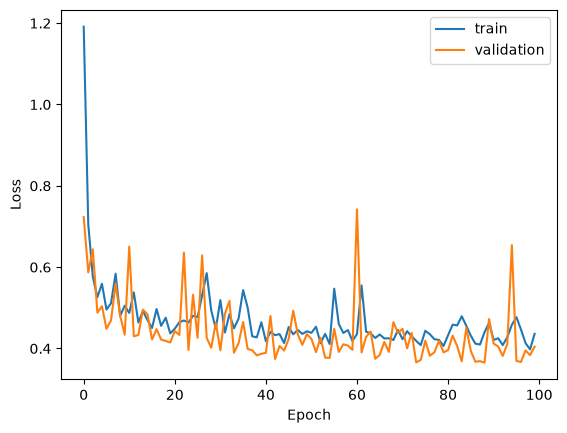

In [37]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'],label='train')
plt.plot(model.history.history['val_loss'],label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()